# GOLD LAYER The Main Analytics & Visualization

## What is the Gold layer?

The Gold layer is the **finished dish**. We take the cleaned Silver data and produce **inference-ready insights**, after aggregation it gives us real ans

## What this notebook does

| # | Plot | What it tells us |
|---|------|------------------|
| 1 | Trip count + avg fare by hour | When is NYC busiest & most expensive? |
| 2 | **Heatmap: hour × day** | Weekday vs weekend rhythm at a glance |
| 3 | Daily trend over the month | Day-by-day variation (seasonality) |
| 4 | Fare distribution histogram | What's the typical fare? Outliers? |
| 5 | Distance vs fare scatter | Is pricing linear with distance? |
| 6 | Box plot: fare by passenger count | Do groups pay more? |
| 7 | Tip % by payment type | Cash vs card tipping behavior |
| 8 | Top 10 pickup hotspots | Where do people hail cabs? |
| 9 | Avg speed by hour | When is NYC traffic worst? |
| 10 | Revenue per hour | When does NYC make the most money? |
| 11 | Trip duration distribution | How long is a typical ride? |


## Step 1: Setup connect to MongoDB and configure plot style 

In [1]:
import warnings
import pandas as pd
import numpy as np
from pymongo import MongoClient
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')

# Plot style: clean, professional
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.family': 'DejaVu Sans',
})

# Connect to MongoDB
client = MongoClient('mongodb://localhost:27017/')
db = client['nyc_taxi']
silver_col = db['silver_trips']

print(f"Silver has {silver_col.count_documents({}):,} clean documents to analyze.")

Silver has 10,837,107 clean documents to analyze.


## Step 2: Build Gold collections (MongoDB aggregations)

We pre-compute summary tables so the plots load instantly. Each Gold collection answers one question.

In [2]:
# Group all trips by hour-of-day. Compute trip count, avg fare, avg distance, avg duration.
db['gold_hourly'].drop()
list(silver_col.aggregate([
    {'$group': {
        '_id': '$pickup_hour',
        'trips': {'$sum': 1},
        'avg_fare': {'$avg': '$fare_amount'},
        'avg_distance': {'$avg': '$trip_distance'},
        'avg_duration': {'$avg': '$trip_duration_minutes'},
        'avg_tip_pct': {'$avg': '$tip_percentage'},
        'total_revenue': {'$sum': '$total_amount'}
    }},
    {'$sort': {'_id': 1}},
    {'$out': 'gold_hourly'}
]))
print(f"gold_hourly: {db['gold_hourly'].count_documents({})} rows (one per hour)")

#  GOLD 2: Hour × Day-of-week (for the heatmap) 
db['gold_hour_dow'].drop()
list(silver_col.aggregate([
    {'$group': {
        '_id': {'hour': '$pickup_hour', 'dow': '$pickup_day_of_week'},
        'trips': {'$sum': 1},
        'avg_fare': {'$avg': '$fare_amount'}
    }},
    {'$out': 'gold_hour_dow'}
]))
print(f"gold_hour_dow: {db['gold_hour_dow'].count_documents({})} rows (one per hour×day)")

#  GOLD 3: Payment type analysis 
db['gold_payment'].drop()
list(silver_col.aggregate([
    {'$group': {
        '_id': '$payment_type',
        'trips': {'$sum': 1},
        'avg_tip_pct': {'$avg': '$tip_percentage'},
        'total_revenue': {'$sum': '$total_amount'}
    }},
    {'$sort': {'trips': -1}},
    {'$out': 'gold_payment'}
]))
print(f"gold_payment: {db['gold_payment'].count_documents({})} rows")

# GOLD 4: Top pickup locations (group by rounded lat/lon)
db['gold_locations'].drop()
list(silver_col.aggregate([
    {'$match': {'pickup_latitude': {'$gt': 40}, 'pickup_longitude': {'$lt': -73}}},  # NYC area
    {'$addFields': {
        'lat_r': {'$round': ['$pickup_latitude', 3]},
        'lon_r': {'$round': ['$pickup_longitude', 3]}
    }},
    {'$group': {
        '_id': {'lat': '$lat_r', 'lon': '$lon_r'},
        'trips': {'$sum': 1},
        'avg_fare': {'$avg': '$fare_amount'}
    }},
    {'$sort': {'trips': -1}},
    {'$limit': 10},
    {'$out': 'gold_locations'}
]))
print(f"gold_locations: {db['gold_locations'].count_documents({})} rows (top 10)")

#  GOLD 5: Daily trend (group by day of month) 
db['gold_daily'].drop()
list(silver_col.aggregate([
    {'$group': {
        '_id': {'$dayOfMonth': '$pickup_datetime'},
        'trips': {'$sum': 1},
        'revenue': {'$sum': '$total_amount'}
    }},
    {'$sort': {'_id': 1}},
    {'$out': 'gold_daily'}
]))
print(f"gold_daily: {db['gold_daily'].count_documents({})} rows (one per day)")

gold_hourly: 24 rows (one per hour)
gold_hour_dow: 168 rows (one per hour×day)
gold_payment: 5 rows
gold_locations: 10 rows (top 10)
gold_daily: 31 rows (one per day)


## Step 3: Load Gold data into pandas DataFrames

We pull the small aggregated collections into pandas so we can plot them easily.

In [3]:
# Load each Gold collection into a DataFrame
df_hourly = pd.DataFrame(list(db['gold_hourly'].find())).sort_values('_id').reset_index(drop=True)
df_hourly = df_hourly.rename(columns={'_id': 'hour'})

df_payment = pd.DataFrame(list(db['gold_payment'].find()))
df_payment = df_payment.rename(columns={'_id': 'payment_type'})

df_locations = pd.DataFrame(list(db['gold_locations'].find()))
df_locations['lat'] = df_locations['_id'].apply(lambda x: x['lat'])
df_locations['lon'] = df_locations['_id'].apply(lambda x: x['lon'])

df_daily = pd.DataFrame(list(db['gold_daily'].find())).sort_values('_id').reset_index(drop=True)
df_daily = df_daily.rename(columns={'_id': 'day'})

# Hour × Day-of-week → pivot into a 2D matrix for the heatmap
hour_dow_data = list(db['gold_hour_dow'].find())
df_hd = pd.DataFrame([{
    'hour': r['_id']['hour'],
    'dow': r['_id']['dow'],
    'avg_fare': r['avg_fare'],
    'trips': r['trips']
} for r in hour_dow_data])

# Also load a sample of Silver for scatter/box plots (need raw rows, not aggregated)
df_sample = pd.DataFrame(list(silver_col.find().limit(50000)))

print("All DataFrames loaded:")
print(f"   df_hourly:    {df_hourly.shape}")
print(f"   df_payment:   {df_payment.shape}")
print(f"   df_locations: {df_locations.shape}")
print(f"   df_daily:     {df_daily.shape}")
print(f"   df_hd:        {df_hd.shape}")
print(f"   df_sample:    {df_sample.shape}  (raw sample for scatter/box plots)")

All DataFrames loaded:
   df_hourly:    (24, 7)
   df_payment:   (5, 4)
   df_locations: (10, 5)
   df_daily:     (31, 3)
   df_hd:        (168, 4)
   df_sample:    (50000, 23)  (raw sample for scatter/box plots)



# PLOT 1: Trip Count + Average Fare by Hour

**Inference:** When demand is highest (rush hour), fares are actually LOWER because rides are short. The most expensive rides happen at dawn 

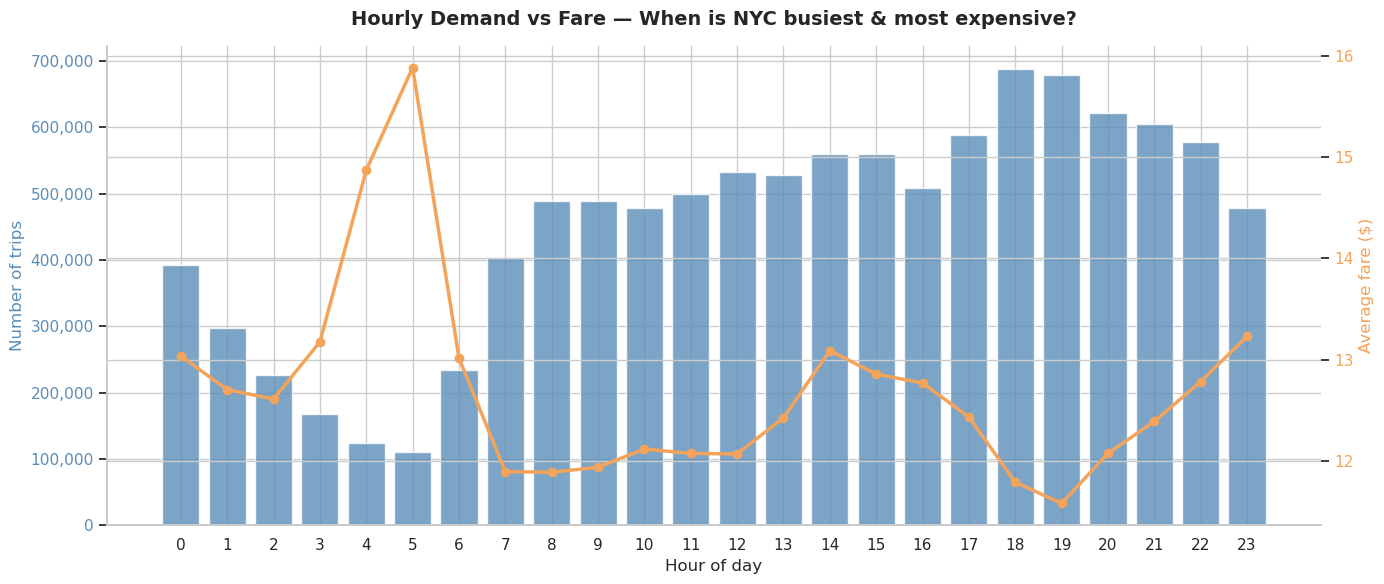


Insight:
   Busiest hour:  18:00 (688,302 trips)
   Priciest hour: 5:00 ($15.88 avg fare)


In [4]:
fig, ax1 = plt.subplots(figsize=(14, 6))

# Bars on the left axis: trip count
ax1.bar(df_hourly['hour'], df_hourly['trips'],
        color='#5B8DB8', alpha=0.8, label='Trip count')
ax1.set_xlabel('Hour of day', fontsize=12)
ax1.set_ylabel('Number of trips', fontsize=12, color='#5B8DB8')
ax1.tick_params(axis='y', labelcolor='#5B8DB8')
ax1.set_xticks(range(24))
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))

# Line on the right axis: average fare
ax2 = ax1.twinx()
ax2.plot(df_hourly['hour'], df_hourly['avg_fare'],
         color='#F4A35A', marker='o', linewidth=2.5, label='Avg fare')
ax2.set_ylabel('Average fare ($)', fontsize=12, color='#F4A35A')
ax2.tick_params(axis='y', labelcolor='#F4A35A')
ax2.spines['top'].set_visible(False)

plt.title('Hourly Demand vs Fare — When is NYC busiest & most expensive?',
          fontsize=14, fontweight='bold', pad=15)
fig.tight_layout()
plt.show()

# Print key insights
peak_hour = df_hourly.loc[df_hourly['trips'].idxmax(), 'hour']
expensive_hour = df_hourly.loc[df_hourly['avg_fare'].idxmax(), 'hour']
print(f"\nInsight:")
print(f"   Busiest hour:  {int(peak_hour)}:00 ({df_hourly['trips'].max():,} trips)")
print(f"   Priciest hour: {int(expensive_hour)}:00 (${df_hourly['avg_fare'].max():.2f} avg fare)")

---
# PLOT 2: Heatmap — Hour × Day-of-Week 



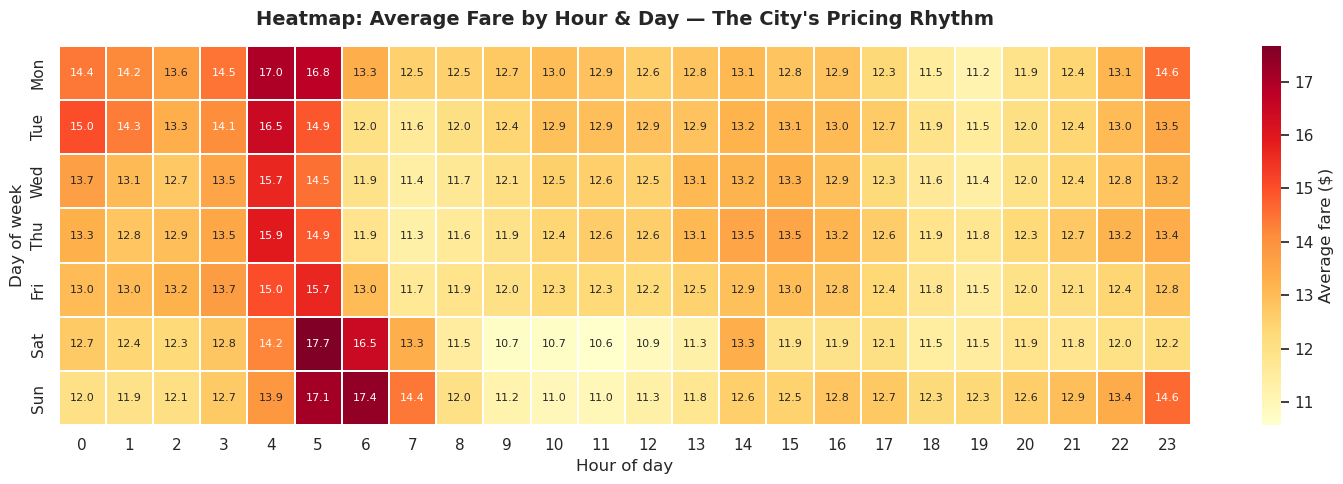

In [5]:
# Pivot the data into a 7×24 matrix: rows=day, cols=hour, values=avg_fare
pivot_fare = df_hd.pivot(index='dow', columns='hour', values='avg_fare')

# MongoDB uses 1=Sun..7=Sat. Reorder to Mon-Sun for readability.
day_names = {1:'Sun', 2:'Mon', 3:'Tue', 4:'Wed', 5:'Thu', 6:'Fri', 7:'Sat'}
pivot_fare.index = [day_names[d] for d in pivot_fare.index]
day_order = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
pivot_fare = pivot_fare.reindex(day_order)

fig, ax = plt.subplots(figsize=(15, 5))
sns.heatmap(pivot_fare, cmap='YlOrRd', annot=True, fmt='.1f',
            cbar_kws={'label': 'Average fare ($)'},
            linewidths=0.3, linecolor='white', ax=ax,
            annot_kws={'fontsize': 8})

ax.set_xlabel('Hour of day', fontsize=12)
ax.set_ylabel('Day of week', fontsize=12)
ax.set_title('Heatmap: Average Fare by Hour & Day — The City\'s Pricing Rhythm',
             fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()


---
# PLOT 3: Daily Trend Trips & Revenue Across the Month



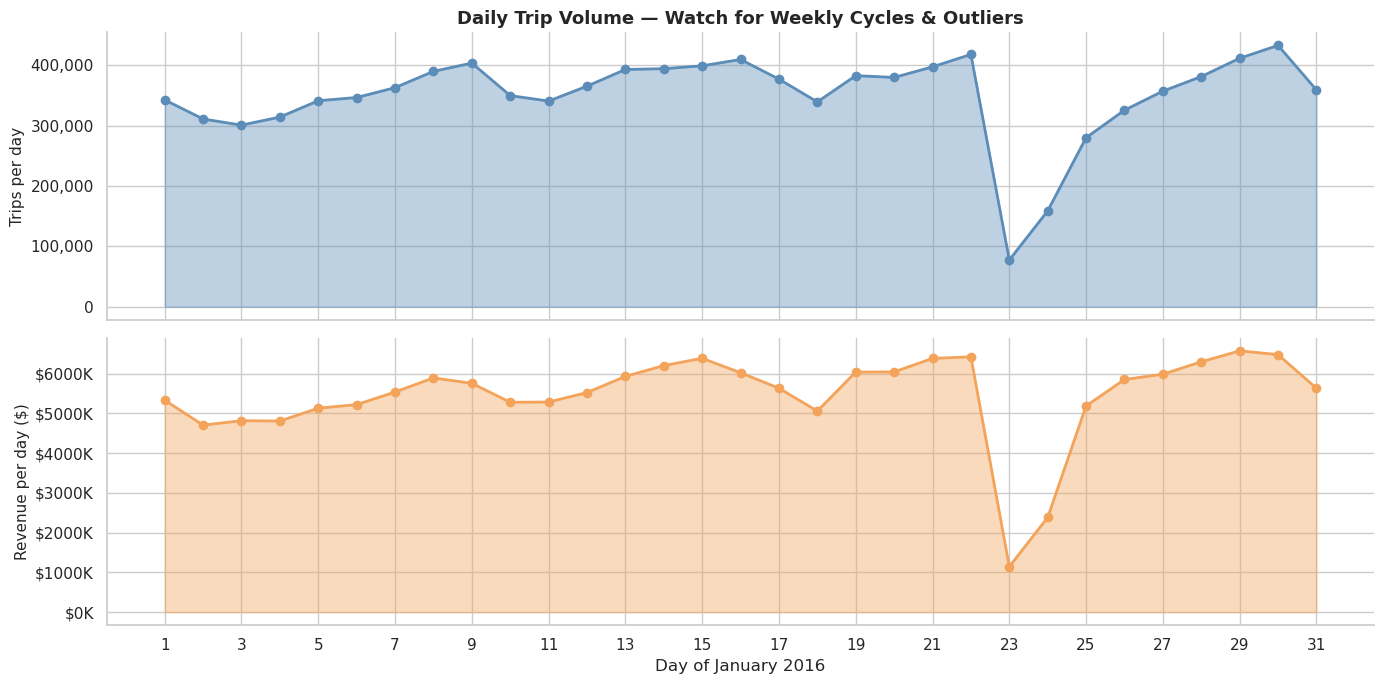

In [6]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

# Top: trips per day
ax1.fill_between(df_daily['day'], df_daily['trips'], color='#5B8DB8', alpha=0.4)
ax1.plot(df_daily['day'], df_daily['trips'], color='#5B8DB8', linewidth=2, marker='o')
ax1.set_ylabel('Trips per day', fontsize=11)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax1.set_title('Daily Trip Volume — Watch for Weekly Cycles & Outliers',
              fontsize=13, fontweight='bold')

# Bottom: revenue per day
ax2.fill_between(df_daily['day'], df_daily['revenue'], color='#F4A35A', alpha=0.4)
ax2.plot(df_daily['day'], df_daily['revenue'], color='#F4A35A', linewidth=2, marker='o')
ax2.set_ylabel('Revenue per day ($)', fontsize=11)
ax2.set_xlabel('Day of January 2016', fontsize=12)
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
ax2.set_xticks(range(1, 32, 2))

plt.tight_layout()
plt.show()


# PLOT 4: Fare Distribution Histogram


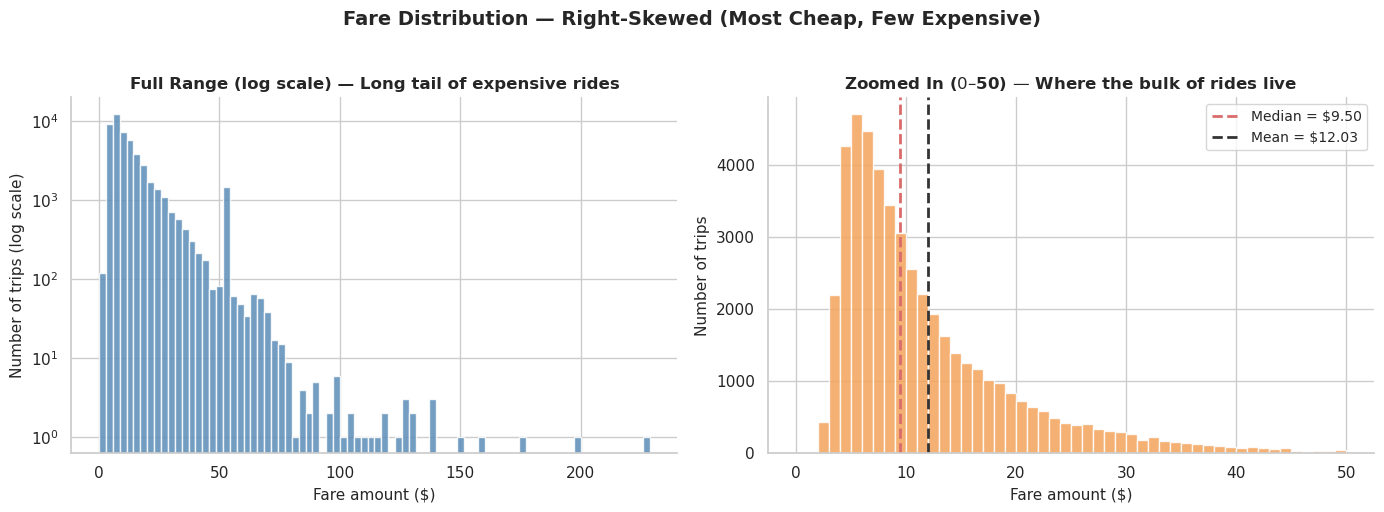

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left: full range with log scale to see the long tail
ax1.hist(df_sample['fare_amount'], bins=80, color='#5B8DB8', alpha=0.85, edgecolor='white')
ax1.set_yscale('log')
ax1.set_xlabel('Fare amount ($)', fontsize=11)
ax1.set_ylabel('Number of trips (log scale)', fontsize=11)
ax1.set_title('Full Range (log scale) — Long tail of expensive rides',
              fontsize=12, fontweight='semibold')

# Right: zoom in on the typical range $0-$50
fare_typical = df_sample[df_sample['fare_amount'] <= 50]['fare_amount']
ax2.hist(fare_typical, bins=50, color='#F4A35A', alpha=0.85, edgecolor='white')
ax2.axvline(fare_typical.median(), color='#D96B6B', linestyle='--', linewidth=2,
            label=f'Median = ${fare_typical.median():.2f}')
ax2.axvline(fare_typical.mean(), color='#333333', linestyle='--', linewidth=2,
            label=f'Mean = ${fare_typical.mean():.2f}')
ax2.set_xlabel('Fare amount ($)', fontsize=11)
ax2.set_ylabel('Number of trips', fontsize=11)
ax2.set_title('Zoomed In ($0–$50) — Where the bulk of rides live',
              fontsize=12, fontweight='semibold')
ax2.legend(fontsize=10)

plt.suptitle('Fare Distribution — Right-Skewed (Most Cheap, Few Expensive)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()




# PLOT 5: Distance vs Fare Scatter (with linear fit)


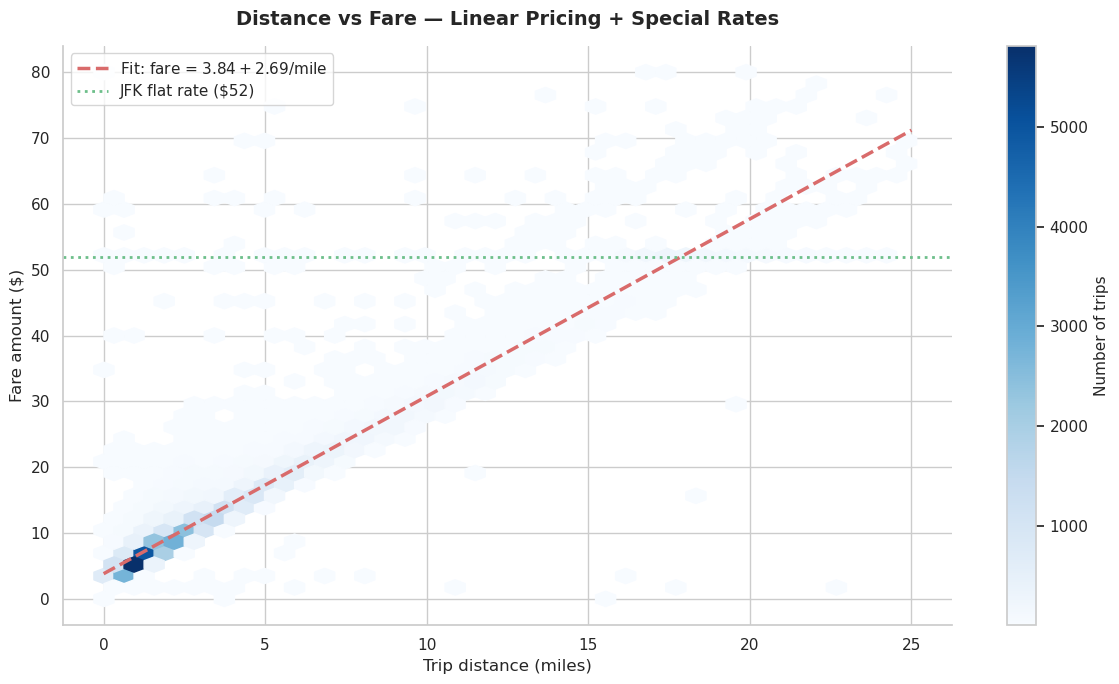

In [8]:
# Filter to a reasonable range for visualization
df_plot = df_sample[(df_sample['trip_distance'] <= 25) & (df_sample['fare_amount'] <= 80)].copy()

fig, ax = plt.subplots(figsize=(12, 7))

# Hexbin density (better than scatter for 50K points)
hb = ax.hexbin(df_plot['trip_distance'], df_plot['fare_amount'],
               gridsize=40, cmap='Blues', mincnt=1)
cbar = plt.colorbar(hb, ax=ax)
cbar.set_label('Number of trips', fontsize=11)

# Linear regression line: fare = a + b * distance
from numpy.polynomial import polynomial as P
coeffs = np.polyfit(df_plot['trip_distance'], df_plot['fare_amount'], deg=1)
x_line = np.linspace(0, 25, 50)
y_line = coeffs[0] * x_line + coeffs[1]
ax.plot(x_line, y_line, color='#D96B6B', linestyle='--', linewidth=2.5,
        label=f'Fit: fare = ${coeffs[1]:.2f} + ${coeffs[0]:.2f}/mile')

# Highlight the JFK flat-rate band at $52
ax.axhline(52, color='#6DBF8A', linestyle=':', linewidth=2,
           label='JFK flat rate ($52)')

ax.set_xlabel('Trip distance (miles)', fontsize=12)
ax.set_ylabel('Fare amount ($)', fontsize=12)
ax.set_title('Distance vs Fare — Linear Pricing + Special Rates',
             fontsize=14, fontweight='bold', pad=15)
ax.legend(loc='upper left', fontsize=11)
plt.tight_layout()
plt.show()



# PLOT 6: Box Plot — Fare by Passenger Count


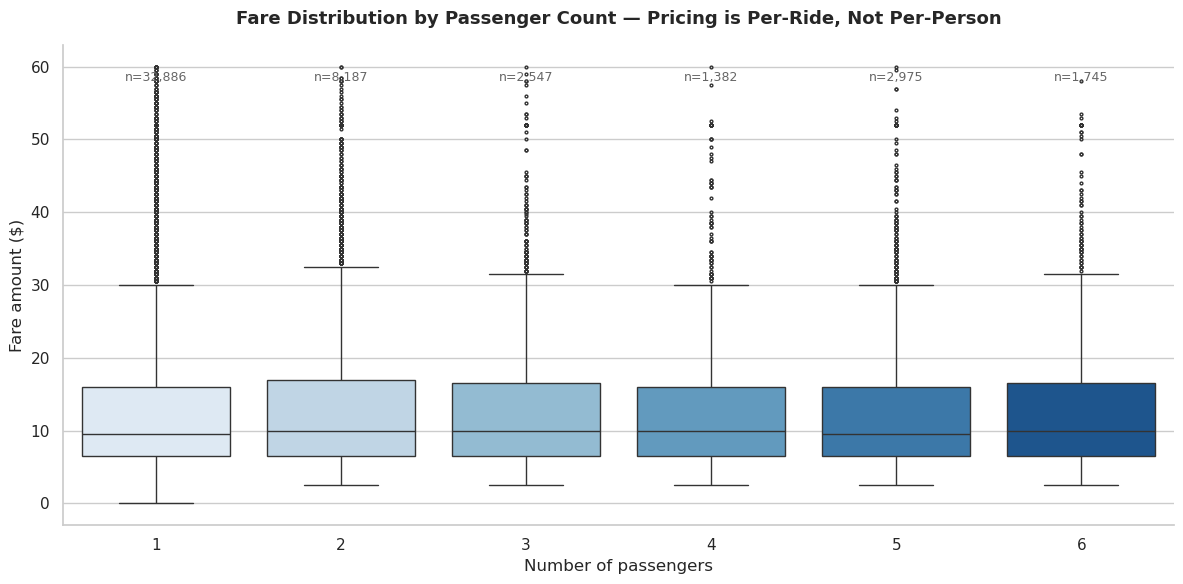

In [9]:

df_box = df_sample[
    (df_sample['passenger_count'].between(1, 6)) &
    (df_sample['fare_amount'] <= 60)
].copy()

fig, ax = plt.subplots(figsize=(12, 6))

sns.boxplot(data=df_box, x='passenger_count', y='fare_amount',
            palette='Blues', ax=ax, fliersize=2)


counts = df_box['passenger_count'].value_counts().sort_index()
for i, count in enumerate(counts.values):
    ax.text(i, 58, f'n={count:,}', ha='center', fontsize=9, color='#666666')

ax.set_xlabel('Number of passengers', fontsize=12)
ax.set_ylabel('Fare amount ($)', fontsize=12)
ax.set_title('Fare Distribution by Passenger Count — Pricing is Per-Ride, Not Per-Person',
             fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()


---
# PLOT 7: Tip % by Payment Type


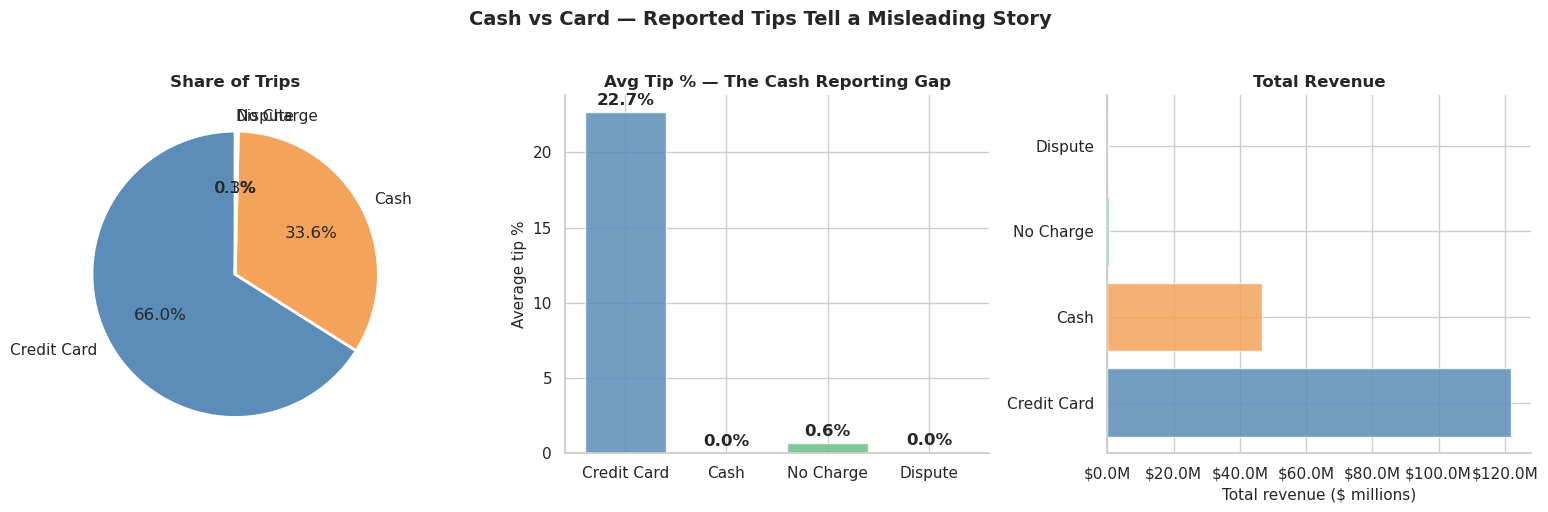

In [10]:
# Map payment_type integers to human-readable names
payment_names = {1: 'Credit Card', 2: 'Cash', 3: 'No Charge', 4: 'Dispute'}
df_payment['name'] = df_payment['payment_type'].map(payment_names)
df_payment_top = df_payment[df_payment['payment_type'].isin([1, 2, 3, 4])].copy()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
colors = ['#5B8DB8', '#F4A35A', '#6DBF8A', '#D96B6B']

# Plot A: Trip share (pie)
axes[0].pie(df_payment_top['trips'], labels=df_payment_top['name'],
            autopct='%1.1f%%', colors=colors, startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[0].set_title('Share of Trips', fontsize=12, fontweight='semibold')

# Plot B: Avg tip %
bars = axes[1].bar(df_payment_top['name'], df_payment_top['avg_tip_pct'],
                    color=colors, alpha=0.85)
axes[1].set_ylabel('Average tip %', fontsize=11)
axes[1].set_title('Avg Tip % — The Cash Reporting Gap', fontsize=12, fontweight='semibold')
for bar, val in zip(bars, df_payment_top['avg_tip_pct']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{val:.1f}%', ha='center', fontweight='bold')

# Plot C: Total revenue (millions)
axes[2].barh(df_payment_top['name'], df_payment_top['total_revenue']/1e6,
             color=colors, alpha=0.85)
axes[2].set_xlabel('Total revenue ($ millions)', fontsize=11)
axes[2].set_title('Total Revenue', fontsize=12, fontweight='semibold')
axes[2].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:.1f}M'))

plt.suptitle('Cash vs Card — Reported Tips Tell a Misleading Story',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


---
# PLOT 8: Top 10 Pickup Hotspots


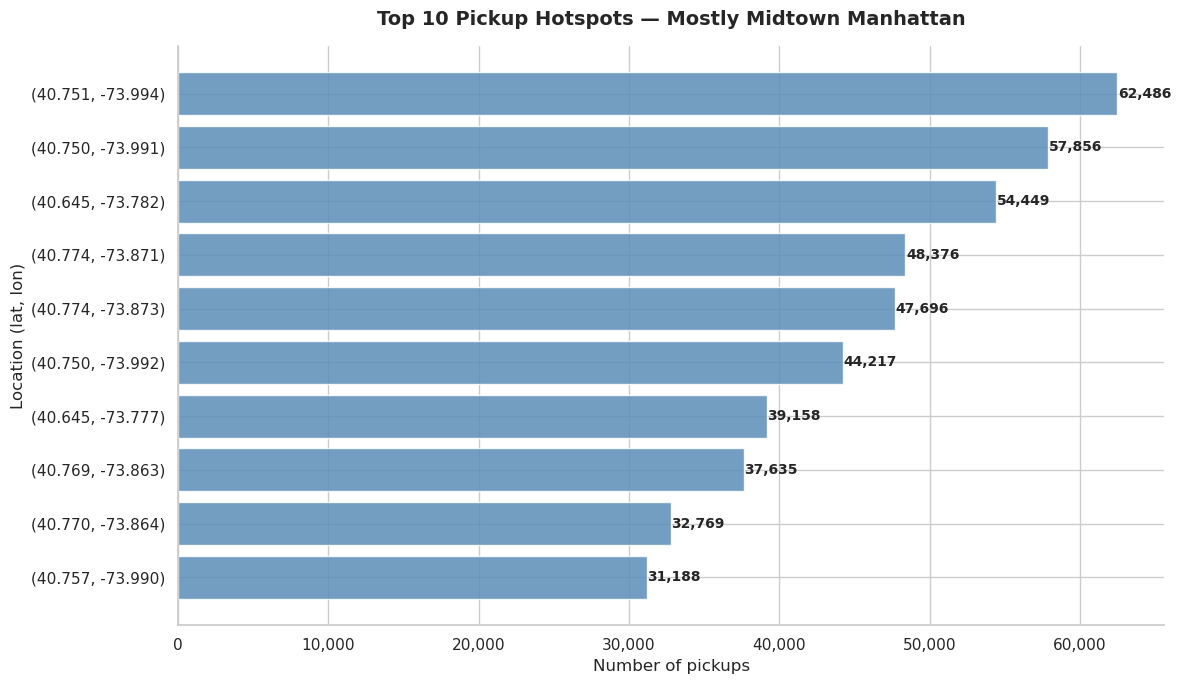

In [11]:
# Build labels with rank + coordinates
df_locations['label'] = df_locations.apply(
    lambda r: f"({r['lat']:.3f}, {r['lon']:.3f})", axis=1
)
df_locations = df_locations.sort_values('trips', ascending=True)

fig, ax = plt.subplots(figsize=(12, 7))

bars = ax.barh(df_locations['label'], df_locations['trips'],
               color='#5B8DB8', alpha=0.85)

# Add count labels
for bar, val in zip(bars, df_locations['trips']):
    ax.text(bar.get_width() + 50, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontsize=10, fontweight='bold')

ax.set_xlabel('Number of pickups', fontsize=12)
ax.set_ylabel('Location (lat, lon)', fontsize=12)
ax.set_title('Top 10 Pickup Hotspots — Mostly Midtown Manhattan',
             fontsize=14, fontweight='bold', pad=15)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()




# PLOT 9: Average Speed by Hour


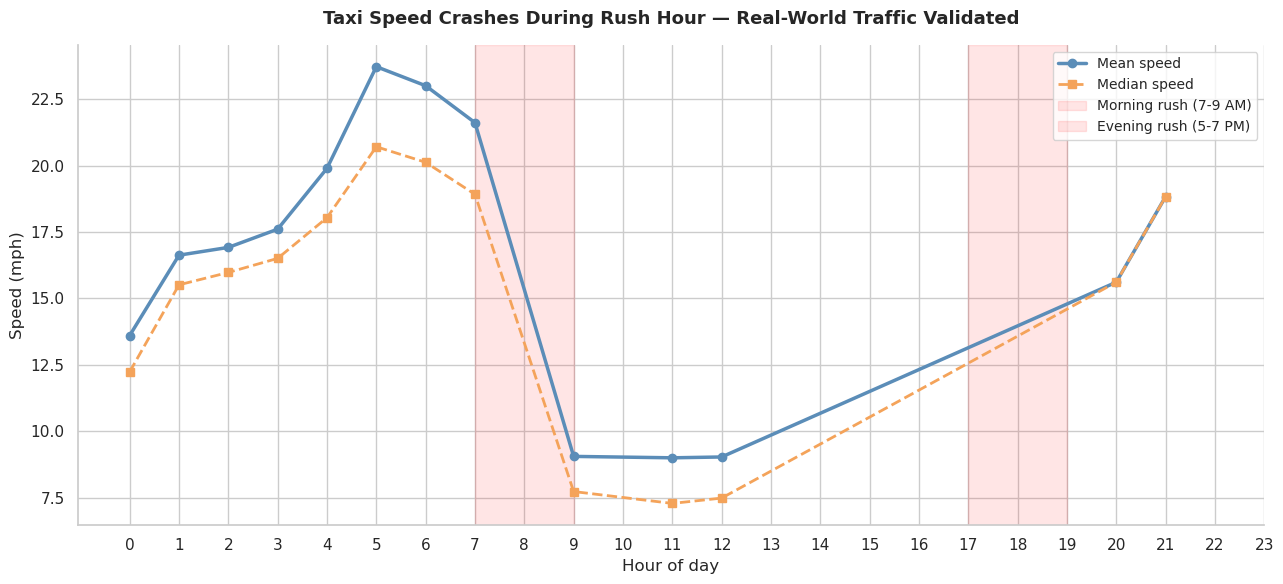

In [12]:
# Compute speed (mph) for each trip in our sample
df_speed = df_sample[
    (df_sample['trip_duration_minutes'] > 0) &
    (df_sample['trip_distance'] > 0)
].copy()
df_speed['speed'] = df_speed['trip_distance'] / (df_speed['trip_duration_minutes'] / 60)
# Remove unrealistic speeds
df_speed = df_speed[(df_speed['speed'] > 1) & (df_speed['speed'] < 80)]

# Aggregate by hour
speed_by_hour = df_speed.groupby('pickup_hour')['speed'].agg(['mean', 'median']).reset_index()

fig, ax = plt.subplots(figsize=(13, 6))

ax.plot(speed_by_hour['pickup_hour'], speed_by_hour['mean'],
        color='#5B8DB8', marker='o', linewidth=2.5, label='Mean speed')
ax.plot(speed_by_hour['pickup_hour'], speed_by_hour['median'],
        color='#F4A35A', marker='s', linewidth=2, linestyle='--', label='Median speed')

# Shade rush hours
ax.axvspan(7, 9, alpha=0.1, color='red', label='Morning rush (7-9 AM)')
ax.axvspan(17, 19, alpha=0.1, color='red', label='Evening rush (5-7 PM)')

ax.set_xlabel('Hour of day', fontsize=12)
ax.set_ylabel('Speed (mph)', fontsize=12)
ax.set_xticks(range(24))
ax.set_title('Taxi Speed Crashes During Rush Hour — Real-World Traffic Validated',
             fontsize=13, fontweight='bold', pad=15)
ax.legend(loc='upper right', fontsize=10)
plt.tight_layout()
plt.show()

fastest = speed_by_hour.loc[speed_by_hour['mean'].idxmax()]
slowest = speed_by_hour.loc[speed_by_hour['mean'].idxmin()]



# PLOT 10: Revenue per Hour



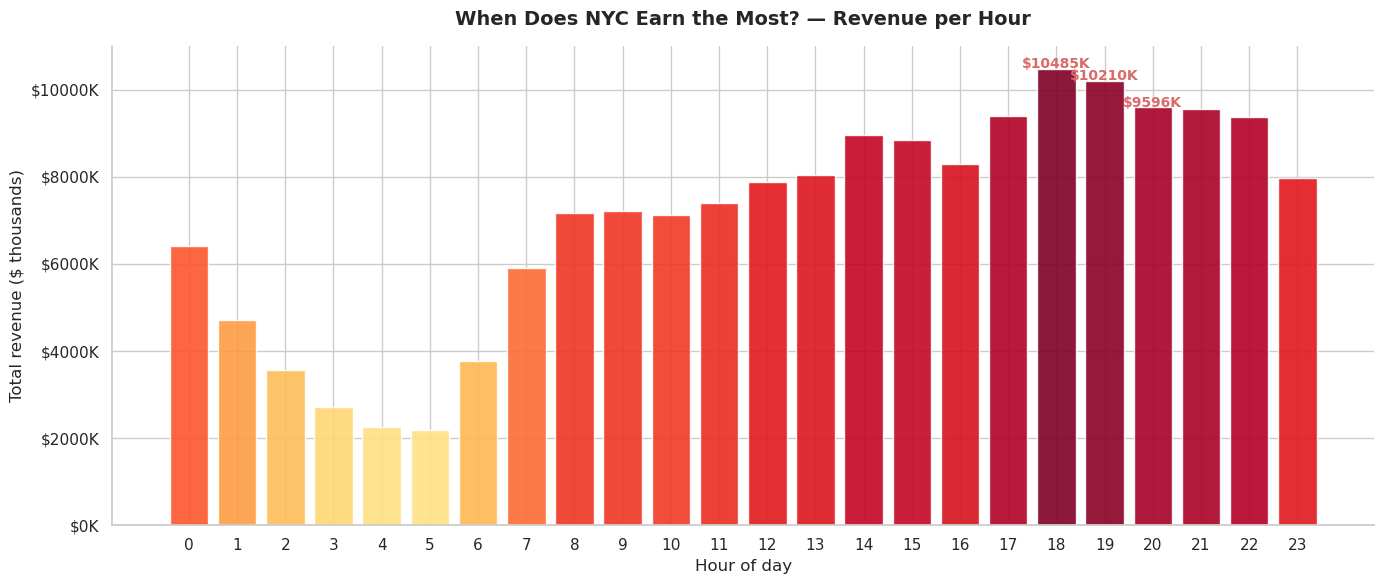

In [13]:
fig, ax = plt.subplots(figsize=(14, 6))

# Color bars by revenue magnitude
colors_rev = plt.cm.YlOrRd(df_hourly['total_revenue'] / df_hourly['total_revenue'].max())
bars = ax.bar(df_hourly['hour'], df_hourly['total_revenue']/1000,
              color=colors_rev, alpha=0.9, edgecolor='white')

# Annotate top 3 hours
top3 = df_hourly.nlargest(3, 'total_revenue')
for _, r in top3.iterrows():
    ax.text(r['hour'], r['total_revenue']/1000 + 5,
            f"${r['total_revenue']/1000:.0f}K",
            ha='center', fontweight='bold', fontsize=10, color='#D96B6B')

ax.set_xlabel('Hour of day', fontsize=12)
ax.set_ylabel('Total revenue ($ thousands)', fontsize=12)
ax.set_xticks(range(24))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${int(x)}K'))
ax.set_title('When Does NYC Earn the Most? — Revenue per Hour',
             fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

best_hour = df_hourly.loc[df_hourly['total_revenue'].idxmax()]



# PLOT 11: Trip Duration Distribution



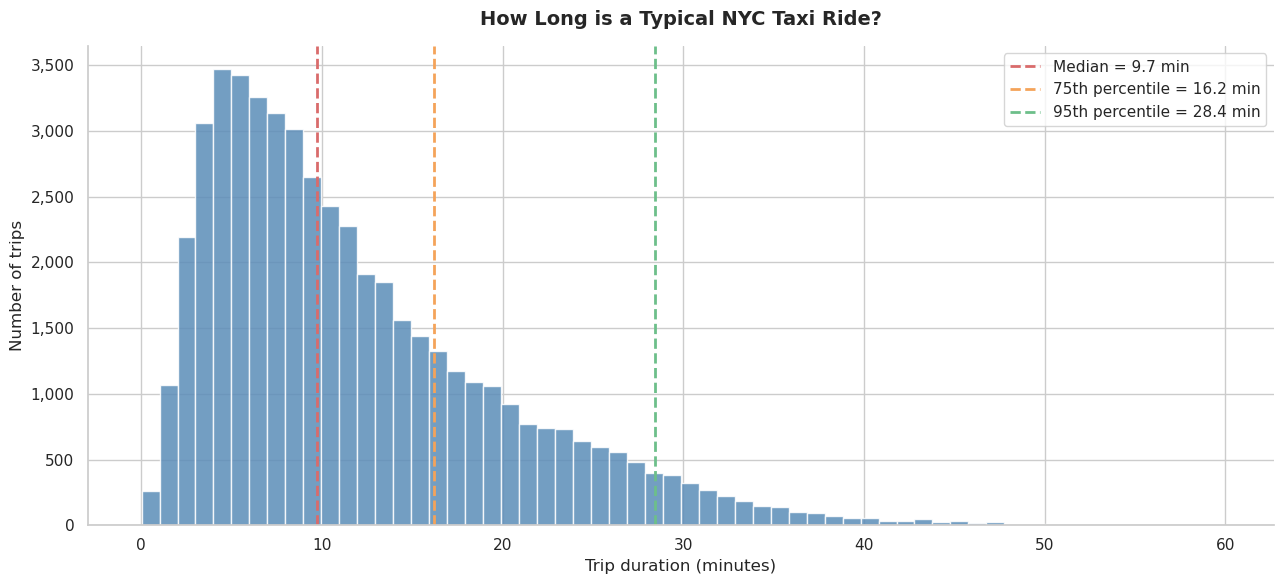

In [14]:
# Filter to realistic durations
df_dur = df_sample[
    (df_sample['trip_duration_minutes'] > 0) &
    (df_sample['trip_duration_minutes'] <= 60)
]

fig, ax = plt.subplots(figsize=(13, 6))

ax.hist(df_dur['trip_duration_minutes'], bins=60,
        color='#5B8DB8', alpha=0.85, edgecolor='white')

# Add markers for median, 75th percentile, 95th percentile
median = df_dur['trip_duration_minutes'].median()
p75 = df_dur['trip_duration_minutes'].quantile(0.75)
p95 = df_dur['trip_duration_minutes'].quantile(0.95)

ax.axvline(median, color='#D96B6B', linestyle='--', linewidth=2,
           label=f'Median = {median:.1f} min')
ax.axvline(p75, color='#F4A35A', linestyle='--', linewidth=2,
           label=f'75th percentile = {p75:.1f} min')
ax.axvline(p95, color='#6DBF8A', linestyle='--', linewidth=2,
           label=f'95th percentile = {p95:.1f} min')

ax.set_xlabel('Trip duration (minutes)', fontsize=12)
ax.set_ylabel('Number of trips', fontsize=12)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.set_title('How Long is a Typical NYC Taxi Ride?',
             fontsize=14, fontweight='bold', pad=15)
ax.legend(fontsize=11, loc='upper right')
plt.tight_layout()
plt.show()
